In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
from datetime import datetime

In [4]:
data_raw = pd.read_csv(r"C:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\Data\Energy Production Dataset_Kaggle.csv",parse_dates=["Date"])

In [5]:
data_raw['Source'].value_counts()

Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64

In [6]:
data=data_raw[data_raw['Source']=="Solar"]

In [7]:
data.reset_index(inplace=True)
data.drop("index",axis=1,inplace=True)

In [8]:
data

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,2025-11-26,12,13,Solar,330,Wednesday,November,Fall,7050
1,2025-11-26,13,14,Solar,330,Wednesday,November,Fall,6697
2,2025-11-26,11,12,Solar,330,Wednesday,November,Fall,6772
3,2025-11-26,14,15,Solar,330,Wednesday,November,Fall,5715
4,2025-11-18,11,12,Solar,322,Tuesday,November,Fall,7764
...,...,...,...,...,...,...,...,...,...
9373,2020-01-05,11,12,Solar,5,Sunday,January,Winter,3282
9374,2020-01-05,15,16,Solar,5,Sunday,January,Winter,2299
9375,2020-01-01,12,13,Solar,1,Wednesday,January,Winter,2544
9376,2020-01-01,14,15,Solar,1,Wednesday,January,Winter,1783


In [9]:
data.sort_values("Date",inplace=True,ignore_index=True,ascending=True)

<Axes: xlabel='Season'>

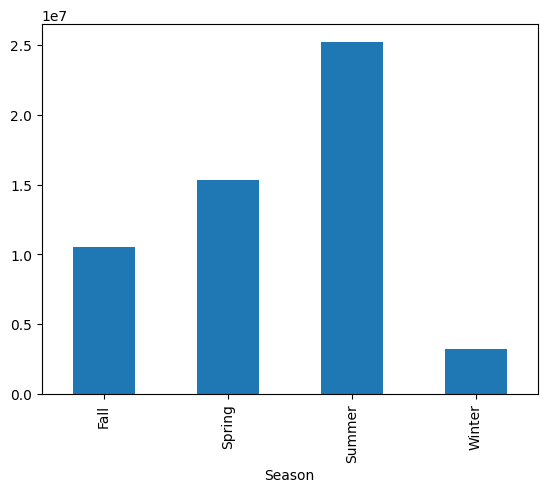

In [10]:
data.groupby("Season")["Production"].sum().plot(kind="bar")

In [11]:
monthly_data=data.groupby("Month_Name")["Production"].sum()

In [12]:
monthly_data

Month_Name
April        5079204
August       8552662
December      588830
February     1654129
January      1002421
July         8591359
June         8074907
March        3561376
May          6666223
November     1365848
October      3489511
September    5708215
Name: Production, dtype: int64

In [13]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

In [14]:
monthly_data.index = pd.CategoricalIndex(monthly_data.index, categories=month_order, ordered=True)

In [15]:
monthly_data.sort_index(inplace=True)

In [16]:
monthly_data

Month_Name
January      1002421
February     1654129
March        3561376
April        5079204
May          6666223
June         8074907
July         8591359
August       8552662
September    5708215
October      3489511
November     1365848
December      588830
Name: Production, dtype: int64

In [17]:
import plotly.express as px
px.bar(x=monthly_data.index, y=monthly_data.values)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
                          'August', 'September', 'October', 'November', 'December'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'tUsPAHE9GQCgVzYApIBNAO+3ZQCbNnsA/xeDANaAggC3GVcA5z41AFjXFAAe/AgA', 'dtype': 'i4'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})

In [18]:
data

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,2020-01-01,13,14,Solar,1,Wednesday,January,Winter,2179
1,2020-01-01,14,15,Solar,1,Wednesday,January,Winter,1783
2,2020-01-01,12,13,Solar,1,Wednesday,January,Winter,2544
3,2020-01-05,12,13,Solar,5,Sunday,January,Winter,3338
4,2020-01-05,13,14,Solar,5,Sunday,January,Winter,3227
...,...,...,...,...,...,...,...,...,...
9373,2025-11-18,11,12,Solar,322,Tuesday,November,Fall,7764
9374,2025-11-26,14,15,Solar,330,Wednesday,November,Fall,5715
9375,2025-11-26,11,12,Solar,330,Wednesday,November,Fall,6772
9376,2025-11-26,13,14,Solar,330,Wednesday,November,Fall,6697


In [19]:
data.isna().sum()

Date           0
Start_Hour     0
End_Hour       0
Source         0
Day_of_Year    0
Day_Name       0
Month_Name     0
Season         0
Production     0
dtype: int64

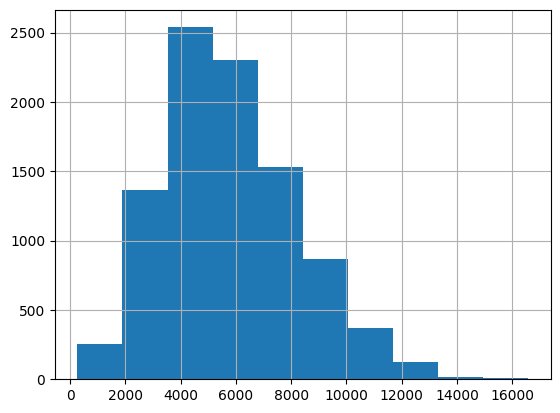

In [20]:
sns.histogram=data["Production"].hist()

In [21]:
year=2023
plt.figure(figsize=(10, 6))
years_1_data = data[data["Date"].dt.year == year]
px.bar(x=years_1_data["Date"], y=years_1_data["Production"])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['2023-01-25T00:00:00.000000000', '2023-01-25T00:00:00.000000000',
                          '2023-01-29T00:00:00.000000000', ..., '2023-12-18T00:00:00.000000000',
                          '2023-12-18T00:00:00.000000000', '2023-12-18T00:00:00.000000000'],
                         shape=(1489,), dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('CQqHC9gOSgtFEZ8RZRIVD00VnxPMFR' ... 'gVygsnFBYV6BBYFK8VBBNPFYsUWxE='),
                    'dtype': 'i2'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})

<Figure size 1000x600 with 0 Axes>

In [22]:
data_tsa = data.set_index("Date")
data_tsa.head()

,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
Date,,,,,,,,
2020-01-01,13,14,Solar,1,Wednesday,January,Winter,2179
2020-01-01,14,15,Solar,1,Wednesday,January,Winter,1783
2020-01-01,12,13,Solar,1,Wednesday,January,Winter,2544
2020-01-05,12,13,Solar,5,Sunday,January,Winter,3338
2020-01-05,13,14,Solar,5,Sunday,January,Winter,3227


In [23]:
data_resampled=data_tsa['Production'].resample("M").sum()
data_resampled

Date
2020-01-31      54551
2020-02-29      41447
2020-03-31     171919
2020-04-30     581932
2020-05-31     762956
               ...   
2025-07-31    2083358
2025-08-31    1868321
2025-09-30     877564
2025-10-31    1012267
2025-11-30     209281
Freq: ME, Name: Production, Length: 71, dtype: int64

In [24]:
data_resampled= pd.DataFrame(data_resampled)
data_resampled

,Production
Date,
2020-01-31,54551
2020-02-29,41447
2020-03-31,171919
2020-04-30,581932
2020-05-31,762956
...,...
2025-07-31,2083358
2025-08-31,1868321
2025-09-30,877564


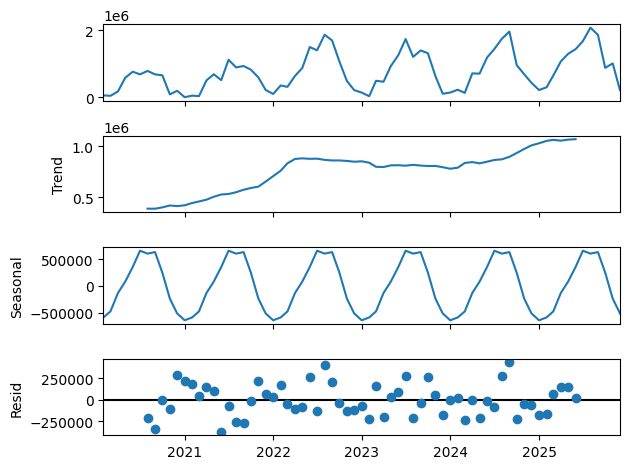

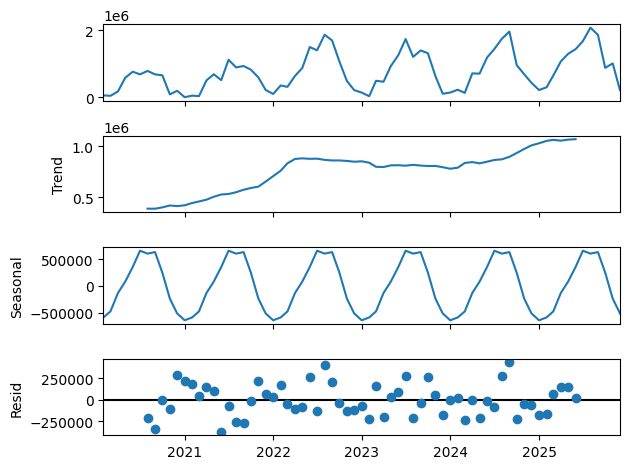

In [25]:
results = seasonal_decompose(data_resampled, model='additive')
results.plot()

In [26]:
adf_test =adfuller(data_resampled)

In [27]:
adf_test

(np.float64(-1.18764293834831),
 np.float64(0.6788886914791441),
 10,
 60,
 {'1%': np.float64(-3.5443688564814813),
  '5%': np.float64(-2.9110731481481484),
  '10%': np.float64(-2.5931902777777776)},
 np.float64(1613.0590458330469))

In [28]:
data_resampled["diff"] = data_resampled.diff()

In [29]:
data_resampled.dropna(inplace=True)

In [30]:
adf_test_2 = adfuller(data_resampled["diff"])

In [31]:
adf_test_2

(np.float64(-7.661892647939087),
 np.float64(1.6801022663539376e-11),
 9,
 60,
 {'1%': np.float64(-3.5443688564814813),
  '5%': np.float64(-2.9110731481481484),
  '10%': np.float64(-2.5931902777777776)},
 np.float64(1612.9704841838525))

In [32]:
auto_arima_model = auto_arima(data_resampled["diff"], seasonal=True, m=12,stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1981.943, Time=1.12 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1996.325, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1989.217, Time=0.48 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1995.681, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1994.328, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1993.699, Time=0.92 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=1986.228, Time=0.82 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=1982.261, Time=2.22 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=inf, Time=1.89 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=1985.815, Time=1.62 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=1980.583, Time=1.35 sec
 ARIMA(1,0,2)(2,0,0)[12] intercept   : AIC=inf, Time=1.34 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=1985.314, Time=0.54 sec
 ARIMA(3,0,2)(2,0,0)[12] intercept

In [33]:
# best_orders=(1,0,4)(2,0,0)[12]

In [34]:
arima_model = ARIMA(data_resampled["Production"], order=(1,0,4))

In [35]:
arima_model=arima_model.fit()

In [36]:
arima_model.fittedvalues

Date
2020-02-29    7.754305e+05
2020-03-31    2.737852e+05
2020-04-30    3.681572e+05
2020-05-31    6.852355e+05
2020-06-30    9.045607e+05
                  ...     
2025-07-31    1.320246e+06
2025-08-31    1.646873e+06
2025-09-30    1.655567e+06
2025-10-31    7.845621e+05
2025-11-30    5.611117e+05
Freq: ME, Length: 70, dtype: float64

In [37]:
data_resampled

,Production,diff
Date,,
2020-02-29,41447,-13104.0
2020-03-31,171919,130472.0
2020-04-30,581932,410013.0
2020-05-31,762956,181024.0
2020-06-30,684460,-78496.0
...,...,...
2025-07-31,2083358,404703.0
2025-08-31,1868321,-215037.0
2025-09-30,877564,-990757.0


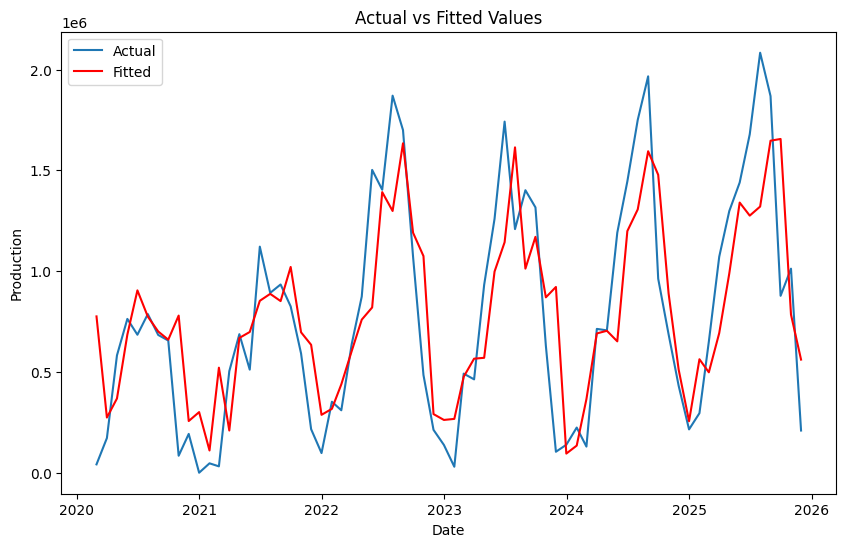

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(data_resampled.index, data_resampled["Production"], label="Actual")
plt.plot(data_resampled.index, arima_model.fittedvalues, label="Fitted", color="red")
plt.title("Actual vs Fitted Values")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [39]:
#error metrics
ARIMA_RMSE = root_mean_squared_error(data_resampled["Production"], arima_model.fittedvalues)
ARIMA_MAE = mean_absolute_error(data_resampled["Production"], arima_model.fittedvalues)
ARIMA_MSE = mean_squared_error(data_resampled["Production"], arima_model.fittedvalues)
print("ARIMA RMSE:", ARIMA_RMSE, "ARIMA MAE:", ARIMA_MAE, "ARIMA MSE:", ARIMA_MSE)

ARIMA RMSE: 334211.9506028962 ARIMA MAE: 252513.58502995083 ARIMA MSE: 111697627925.79274


In [40]:
SARIMAX_model = SARIMAX(data_resampled["Production"], order=(1,1,4), seasonal_order=(2,0,0,12)) 
SARIMAX_model = SARIMAX_model.fit()

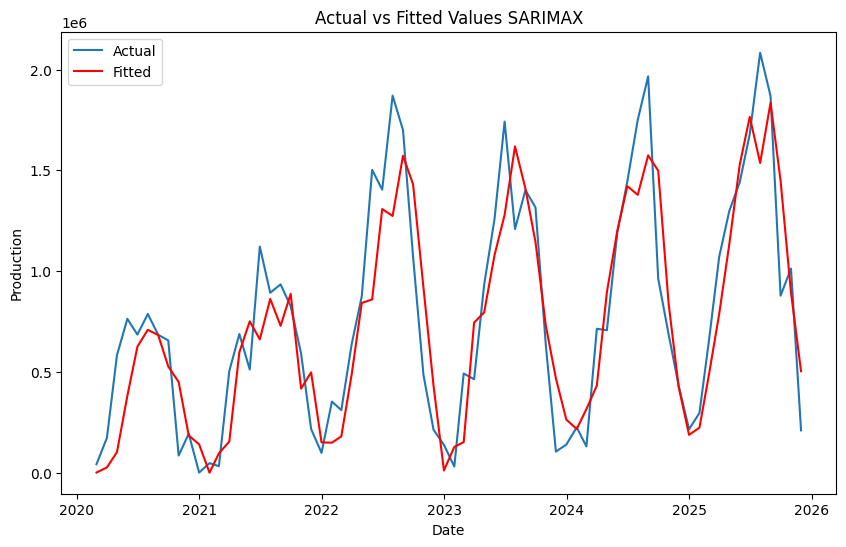

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(data_resampled.index, data_resampled["Production"], label="Actual")
plt.plot(data_resampled.index, SARIMAX_model.fittedvalues, label="Fitted", color="red")
plt.title("Actual vs Fitted Values SARIMAX")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [42]:
#error metrics for SARIMAX
SARIMAX_RMSE = root_mean_squared_error(data_resampled["Production"], SARIMAX_model.fittedvalues)
SARIMAX_MAE = mean_absolute_error(data_resampled["Production"], SARIMAX_model.fittedvalues)
SARIMAX_MSE = mean_squared_error(data_resampled["Production"], SARIMAX_model.fittedvalues)
print("SARIMAX RMSE:", SARIMAX_RMSE, "SARIMAX MAE:", SARIMAX_MAE, "SARIMAX MSE:", SARIMAX_MSE)

SARIMAX RMSE: 263587.19662440504 SARIMAX MAE: 204186.43016747804 SARIMAX MSE: 69478210224.31277


In [43]:
sarimax_residuals=SARIMAX_model.resid

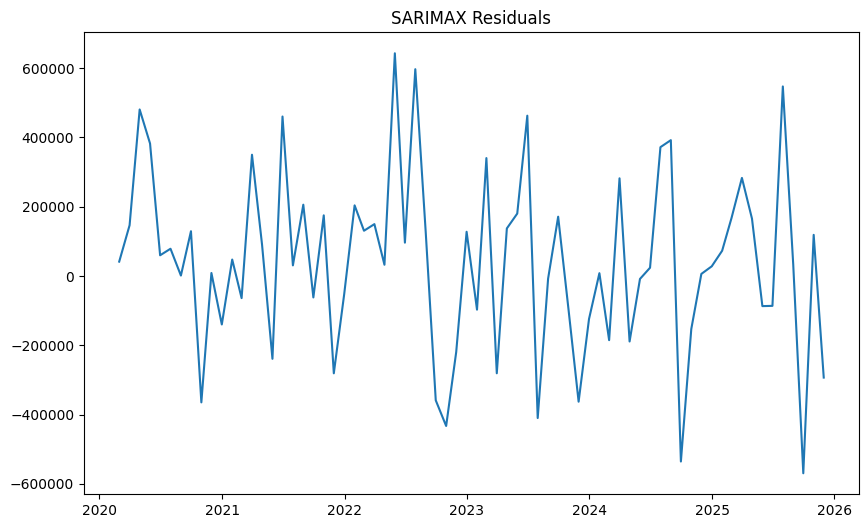

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(sarimax_residuals)
plt.title("SARIMAX Residuals")
plt.show()

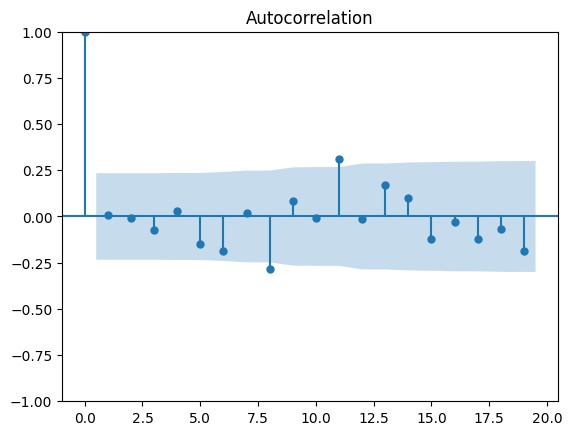

In [45]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sarimax_residuals)
plt.show()

In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(sarimax_residuals, lags=[10], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
10  12.115336   0.277412


In [47]:
print(sarimax_residuals.mean())

41232.62971694522


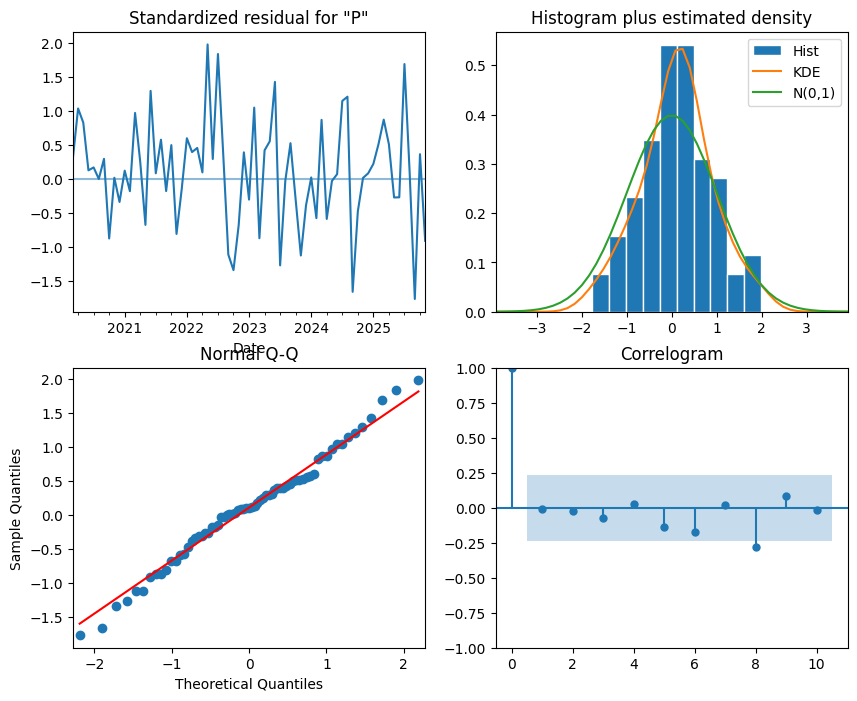

In [48]:
SARIMAX_model.plot_diagnostics(figsize=(10, 8))
plt.show()

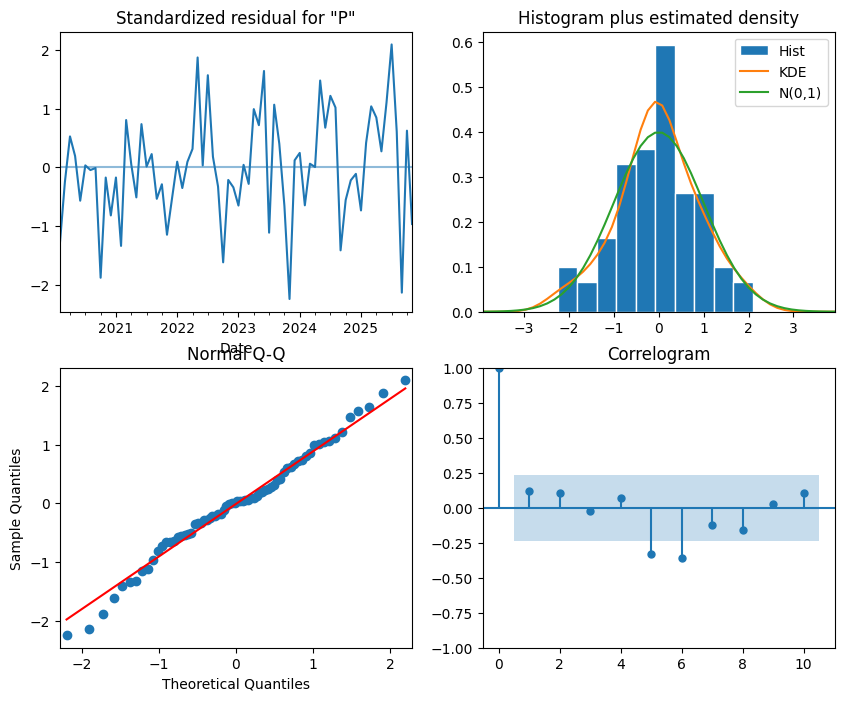

In [49]:
arima_model.plot_diagnostics(figsize=(10, 8))
plt.show()

In [50]:
data_resampled

,Production,diff
Date,,
2020-02-29,41447,-13104.0
2020-03-31,171919,130472.0
2020-04-30,581932,410013.0
2020-05-31,762956,181024.0
2020-06-30,684460,-78496.0
...,...,...
2025-07-31,2083358,404703.0
2025-08-31,1868321,-215037.0
2025-09-30,877564,-990757.0


In [51]:
import math

In [52]:
data_resampled['Log_Production'] = data_resampled['Production'].apply(lambda x: math.log(x) if x > 0 else 0)

In [53]:
data_resampled

,Production,diff,Log_Production
Date,,,
2020-02-29,41447,-13104.0,10.632171
2020-03-31,171919,130472.0,12.054779
2020-04-30,581932,410013.0,13.274109
2020-05-31,762956,181024.0,13.544956
2020-06-30,684460,-78496.0,13.436385
...,...,...,...
2025-07-31,2083358,404703.0,14.549492
2025-08-31,1868321,-215037.0,14.440551
2025-09-30,877564,-990757.0,13.684905


In [54]:
# best_orders=(1,0,4)(2,0,0)[12]

In [55]:
log_sarimax_model = SARIMAX(data_resampled["Log_Production"], order=(1,0,4), seasonal_order=(2,0,0,12))
log_sarimax_model = log_sarimax_model.fit()

In [56]:
data_resampled['Log_fittedvalues'] = log_sarimax_model.fittedvalues

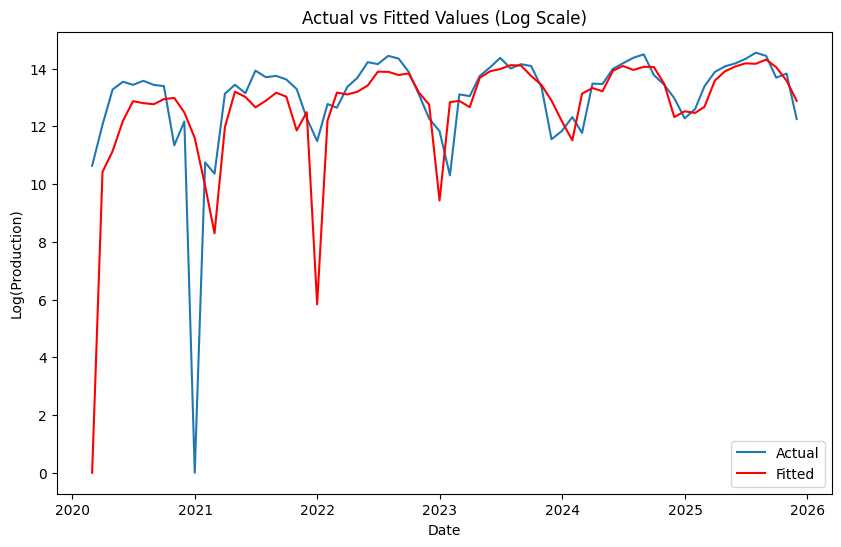

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(data_resampled.index, data_resampled["Log_Production"], label="Actual")
plt.plot(data_resampled.index, data_resampled["Log_fittedvalues"], label="Fitted", color="red")
plt.title("Actual vs Fitted Values (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Log(Production)")   
plt.legend()
plt.show()

In [58]:
log_MAE = mean_absolute_error(data_resampled["Log_Production"], data_resampled["Log_fittedvalues"])
log_MSE = mean_squared_error(data_resampled["Log_Production"], data_resampled["Log_fittedvalues"])
log_RMSE = root_mean_squared_error(data_resampled["Log_Production"], data_resampled["Log_fittedvalues"])
print("Log SARIMAX MAE:", log_MAE)
print("Log SARIMAX MSE:", log_MSE)
print("Log SARIMAX RMSE:", log_RMSE)


Log SARIMAX MAE: 0.9694960841025875
Log SARIMAX MSE: 4.66334958760866
Log SARIMAX RMSE: 2.1594790083741633


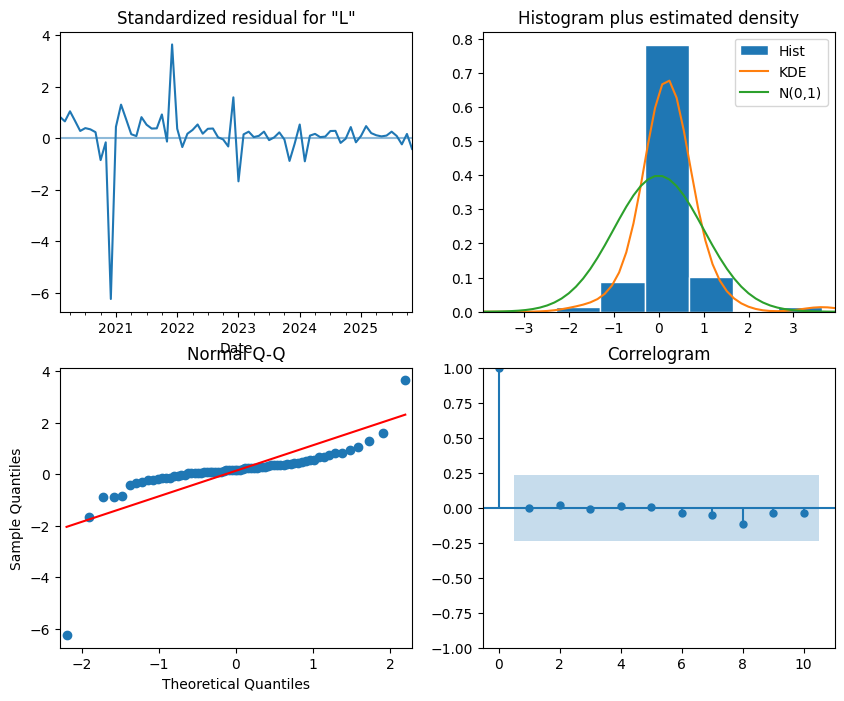

In [59]:
log_sarimax_model.plot_diagnostics(figsize=(10, 8))
plt.show()

<Axes: ylabel='Production'>

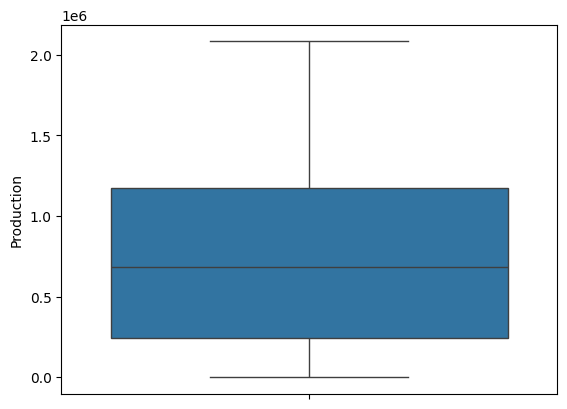

In [60]:
sns.boxplot(data_resampled['Production'])

In [61]:
data

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,2020-01-01,13,14,Solar,1,Wednesday,January,Winter,2179
1,2020-01-01,14,15,Solar,1,Wednesday,January,Winter,1783
2,2020-01-01,12,13,Solar,1,Wednesday,January,Winter,2544
3,2020-01-05,12,13,Solar,5,Sunday,January,Winter,3338
4,2020-01-05,13,14,Solar,5,Sunday,January,Winter,3227
...,...,...,...,...,...,...,...,...,...
9373,2025-11-18,11,12,Solar,322,Tuesday,November,Fall,7764
9374,2025-11-26,14,15,Solar,330,Wednesday,November,Fall,5715
9375,2025-11-26,11,12,Solar,330,Wednesday,November,Fall,6772
9376,2025-11-26,13,14,Solar,330,Wednesday,November,Fall,6697


In [ ]:
data_lstm = data.copy()

: 